In [2]:
# Indoor Air Quality Dataset Post-Processing and Balancing Notebook
# ================================================================
# This notebook performs the full post-collection pipeline for the indoor mobile IAQ dataset.
# Input: dataset.csv (raw synchronized data collected by the robotic car)
# Output: FinalDataset.csv (enriched dataset with QC metrics, derived features, and calibration)
# /metadata and /figures folders with documentation and plots.

# Cell 0: Imports & Configuration

In [1]:
# ==========================================================
# Cell 0 — Imports & Global Configuration
# ==========================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# ----------------------------------------------------------
# Sampling & Quality-Control Parameters
# ----------------------------------------------------------
SAMPLING_RATE = 5          # Hz (environmental sensors)
WINDOW_SEC = 30
WINDOW_SAMPLES = SAMPLING_RATE * WINDOW_SEC
MAD_THRESHOLD = 6
Z_THRESHOLD = 4
FLATLINE_EPS = 1e-3
FLATLINE_MIN_SEC = 60      # Minimum duration for flatline flag (s)

# ----------------------------------------------------------
# IMU Calibration Settings
# ----------------------------------------------------------
IMU_CAL_SAMPLES = 50       # First N samples assumed stationary → bias estimation
GRAVITY = 9.80665          # m/s² (used for accel scaling to Earth gravity)

# ----------------------------------------------------------
# Dataset Directory Structure (FAIR-compliant)
# ----------------------------------------------------------
BASE_DATASET_DIR = "Dataset"
FIGURES_DIRNAME = "Figures"
LIDAR_CAMERA_DIRNAME = "lidar_camera_data"

# Ensure base directory exists
os.makedirs(BASE_DATASET_DIR, exist_ok=True)

# ----------------------------------------------------------
# Plot Styling (consistent across all figures)
# ----------------------------------------------------------
sns.set_style("whitegrid")
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "legend.fontsize": 8,
    "figure.dpi": 120
})

print(f"✅ Environment initialized — Base dataset folder: {os.path.abspath(BASE_DATASET_DIR)}")


✅ Environment initialized — Base dataset folder: /Users/mohammedal-salahi/Desktop/Code3/Dataset


# Cell 1: Load, Align, and Basic Sanitization


In [2]:
# ==========================================================
# Cell 1 — Load, Align, and Basic Sanitization
# ==========================================================

# Path to raw dataset
INPUT_PATH = "new_dataset.csv"  # Replace with your data file if different

print(f"📂 Loading raw dataset from: {INPUT_PATH}")
df = pd.read_csv(INPUT_PATH, parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"✅ Dataset loaded successfully with {df.shape[0]} records and {df.shape[1]} columns.")
print(f"Columns detected: {list(df.columns)}\n")

# ----------------------------------------------------------
# Basic Plausibility Filtering
# ----------------------------------------------------------
def mark_plausibility(df, col, low, high):
    """Adds a boolean column marking values outside [low, high] as invalid."""
    if col in df.columns:
        df[f"{col}_invalid"] = (df[col] < low) | (df[col] > high)
    else:
        print(f"⚠️  Column '{col}' not found — skipping plausibility check.")
    return df

# Initialize global quality flag
df["quality_flag"] = 0

# Apply plausibility filters to environmental sensors
df = mark_plausibility(df, "co2_ppm", 300, 10000)
df = mark_plausibility(df, "rh_pct", 0, 100)
df = mark_plausibility(df, "temp_c", -10, 60)

# ----------------------------------------------------------
# Check for required grouping columns
# ----------------------------------------------------------
if not {"room_label", "run_id"}.issubset(df.columns):
    raise ValueError("❌ Dataset must include 'room_label' and 'run_id' columns for grouping.")

# Identify all unique (room_label, run_id) combinations
group_keys = df[["room_label", "run_id"]].drop_duplicates().values.tolist()
print(f"📊 Found {len(group_keys)} unique room/run combinations:")
for room, run in group_keys:
    print(f"   • {room} | {run}")

# ----------------------------------------------------------
# Prepare directory structure for each run (no processing yet)
# ----------------------------------------------------------
for room_label, run_id in group_keys:
    group_dir = os.path.join(BASE_DATASET_DIR, f"{room_label}_{run_id}")
    os.makedirs(group_dir, exist_ok=True)
    os.makedirs(os.path.join(group_dir, FIGURES_DIRNAME), exist_ok=True)
    os.makedirs(os.path.join(group_dir, LIDAR_CAMERA_DIRNAME), exist_ok=True)
    print(f"✅ Created base directory for: {room_label}_{run_id}")

print("\n✅ All run directories initialized — ready for processing.")


📂 Loading raw dataset from: new_dataset.csv
✅ Dataset loaded successfully with 2707 records and 21 columns.
Columns detected: ['timestamp', 'co2_ppm', 'pm1_ugm3', 'pm25_ugm3', 'pm10_ugm3', 'temp_c', 'rh_pct', 'pressure_hpa', 'altitude_m', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z', 'mag_x', 'mag_y', 'mag_z', 'room_label', 'run_id', 'quality_flag']

📊 Found 4 unique room/run combinations:
   • classroom_window_closed | run_1
   • mech_workshop | run_2
   • bedroom_window_open | run_3
   • bedroom_window_closed | run_4
✅ Created base directory for: classroom_window_closed_run_1
✅ Created base directory for: mech_workshop_run_2
✅ Created base directory for: bedroom_window_open_run_3
✅ Created base directory for: bedroom_window_closed_run_4

✅ All run directories initialized — ready for processing.


# Cell 2: Spike Detection (MAD and Rolling Z-score)


In [3]:
# ==========================================================
# Cell 2 — Spike Detection Visualization (MAD & Z-score)
# ==========================================================

def plot_spike_detection_group(group_df, room_label, run_id, variables, output_dir, time_col="timestamp"):
    """
    Plot and save spike detection results for each variable within a room/run group.
    Adds figure titles, labeled axes, and saves plots under Dataset/<room>_<run>/Figures/.
    """
    for var in variables:
        spike_col = f"{var}_spike_flag"
        if spike_col not in group_df.columns:
            print(f"⚠️  Spike flag column not found for {var}, skipping.")
            continue

        plt.figure(figsize=(8, 3))
        plt.plot(group_df[time_col], group_df[var], label="Value", color="#1f77b4", linewidth=0.8)
        plt.scatter(
            group_df.loc[group_df[spike_col] == 1, time_col],
            group_df.loc[group_df[spike_col] == 1, var],
            color='red', s=10, label="Spike"
        )

        plt.title(f"Spike Detection for {var} — {room_label} ({run_id})")
        plt.xlabel("Time (s)")
        plt.ylabel(f"{var.replace('_', ' ').title()} Measurement")
        plt.legend(fontsize=7)
        plt.tight_layout()

        # Save figure before showing to ensure proper export in all environments
        fig_path = os.path.join(output_dir, f"SpikeDetection_{var}.png")
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        print(f"💾 Saved spike detection plot: {fig_path}")

        # Show inline for inspection
        plt.show()
        plt.close()

# Example usage inside the processing loop (Cell 6):
# plot_spike_detection_group(
#     group_df=group_df,
#     room_label=room_label,
#     run_id=run_id,
#     variables=["co2_ppm", "pm25_ugm3"],
#     output_dir=os.path.join(group_path, FIGURES_DIRNAME)
# )


# Cell 3: Flatline (Stuck Sensor) Detection


In [4]:
# ==========================================================
# Cell 3 — Flatline (Stuck Sensor) Detection
# ==========================================================

def detect_flatline(series, eps=FLATLINE_EPS, min_len=SAMPLING_RATE * FLATLINE_MIN_SEC):
    """
    Detect flatline (stuck) behavior in a numeric time series.

    Parameters
    ----------
    series : pd.Series
        Sensor signal.
    eps : float
        Threshold below which change is considered negligible.
    min_len : int
        Minimum consecutive sample count (at SAMPLING_RATE) to declare a flatline.

    Returns
    -------
    flatline_count : int
        Number of flatline segments detected.
    flatline_flag : pd.Series
        Boolean flag (True = within flatline segment).
    """
    if series.isna().all():
        return 0, pd.Series(False, index=series.index)

    d = series.diff().abs().fillna(0)
    stuck = d < eps

    flatline_flag = pd.Series(False, index=series.index)
    run_points = 0
    count = 0

    for i, val in enumerate(stuck):
        if val:
            run_points += 1
            # once threshold reached, flag segment as flatline
            if run_points >= min_len:
                flatline_flag.iloc[i - run_points + 1 : i + 1] = True
                count += 1
        else:
            run_points = 0

    return count, flatline_flag


# Cell 4: Sensor Calibration & Consistency


In [5]:
# ==========================================================
# Cell 4 — Sensor Calibration & Consistency
# ==========================================================

# Placeholder calibration constants (to be refined during validation)
calibration_constants = {
    # Environmental sensors
    "co2_ppm":   {"model": "linear", "params": {"a": 1.0, "b": 0.0}},
    "pm25_ugm3": {"model": "linear", "params": {"a": 1.0, "b": 0.0}},
    "pm10_ugm3": {"model": "linear", "params": {"a": 1.0, "b": 0.0}},
    "pm1_ugm3":  {"model": "linear", "params": {"a": 1.0, "b": 0.0}},

    # IMU sensors (placeholders — bias and scale will be computed later)
    "accel": {"model": "bias_scale", "params": {"bias": [0.0, 0.0, 0.0], "scale": [1.0, 1.0, 1.0]}},
    "gyro":  {"model": "bias_scale", "params": {"bias": [0.0, 0.0, 0.0], "scale": [1.0, 1.0, 1.0]}},
    "mag":   {"model": "bias_scale", "params": {"bias": [0.0, 0.0, 0.0], "scale": [1.0, 1.0, 1.0]}},
}

# Create base dataset directory (if not yet created)
os.makedirs(BASE_DATASET_DIR, exist_ok=True)

# Save a master calibration reference file at the Dataset root
master_cal_path = os.path.join(BASE_DATASET_DIR, "calibration_master.json")
with open(master_cal_path, "w") as f:
    json.dump(calibration_constants, f, indent=4)

print(f"💾 Master calibration constants saved → {master_cal_path}")

# The same dictionary will later be saved per run after IMU calibration
# (in each Dataset/<room_label>_<run_id>/calibration.json)

# Return calibration constants for use in later steps
calibration_constants


💾 Master calibration constants saved → Dataset/calibration_master.json


{'co2_ppm': {'model': 'linear', 'params': {'a': 1.0, 'b': 0.0}},
 'pm25_ugm3': {'model': 'linear', 'params': {'a': 1.0, 'b': 0.0}},
 'pm10_ugm3': {'model': 'linear', 'params': {'a': 1.0, 'b': 0.0}},
 'pm1_ugm3': {'model': 'linear', 'params': {'a': 1.0, 'b': 0.0}},
 'accel': {'model': 'bias_scale',
  'params': {'bias': [0.0, 0.0, 0.0], 'scale': [1.0, 1.0, 1.0]}},
 'gyro': {'model': 'bias_scale',
  'params': {'bias': [0.0, 0.0, 0.0], 'scale': [1.0, 1.0, 1.0]}},
 'mag': {'model': 'bias_scale',
  'params': {'bias': [0.0, 0.0, 0.0], 'scale': [1.0, 1.0, 1.0]}}}

# Cell 5: Feature Engineering & Derived Parameters


In [6]:
# ==========================================================
# Cell 5 — Feature Engineering & Derived Parameters
# ==========================================================

# ----------------------------------------------------------
# Rolling Mean & Standard Deviation
# ----------------------------------------------------------
def add_rolling_features(df, col, window=WINDOW_SAMPLES):
    """
    Adds rolling mean and standard deviation for a given column.
    Uses 'min_periods=1' to ensure the feature is defined for all samples.
    """
    if col not in df.columns:
        print(f"⚠️ Skipping rolling features for '{col}' (column missing).")
        return df

    df[f"{col}_roll_mean"] = df[col].rolling(window, min_periods=1).mean()
    df[f"{col}_roll_std"] = df[col].rolling(window, min_periods=1).std()
    return df


# ----------------------------------------------------------
# Psychrometric Calculations
# ----------------------------------------------------------
def dew_point(temp_c, rh):
    """
    Calculates dew point temperature (°C) from air temperature and relative humidity.
    Uses the Magnus-Tetens approximation.
    """
    a, b = 17.62, 243.12
    rh_clipped = np.clip(rh, 1e-3, 100)  # prevent log(0)
    gamma = np.log(rh_clipped / 100) + (a * temp_c) / (b + temp_c)
    return (b * gamma) / (a - gamma)


def absolute_humidity(temp_c, rh):
    """
    Calculates absolute humidity (g/m³) from temperature (°C) and relative humidity (%).
    Based on the Clausius–Clapeyron relation.
    """
    rh_clipped = np.clip(rh, 0, 100)
    return (
        6.112 * np.exp((17.67 * temp_c) / (temp_c + 243.5)) * rh_clipped * 2.1674 / (273.15 + temp_c)
    )


# Cell 6: IMU Calibration & Visualization


In [9]:
# ==========================================================
# NEW CELL — IMU Calibration & Visualization (Improved Plots)
# ==========================================================

def calibrate_and_plot_imu(group_df, room_label, run_id, output_dir, n_calib_samples=IMU_CAL_SAMPLES):
    """
    Calibrates accelerometer, gyroscope, and magnetometer data by removing bias
    and scaling accelerometer to match gravity magnitude (~9.81 m/s²).
    Generates and saves side-by-side comparison plots (raw vs calibrated) for each IMU type.
    """
    imu_axes = {
        "accel": ["accel_x", "accel_y", "accel_z"],
        "gyro":  ["gyro_x", "gyro_y", "gyro_z"],
        "mag":   ["mag_x", "mag_y", "mag_z"],
    }

    os.makedirs(output_dir, exist_ok=True)
    imu_calibration = {}

    for sensor_type, axes in imu_axes.items():
        missing = [ax for ax in axes if ax not in group_df.columns]
        if missing:
            print(f"⚠️ Skipping {sensor_type} calibration — missing columns: {missing}")
            continue

        # --- Calibration ---
        stationary_data = group_df[axes].iloc[:n_calib_samples]
        bias = stationary_data.mean().values
        calibrated = group_df[axes] - bias

        # For accelerometer: normalize to gravity magnitude
        if sensor_type == "accel":
            mag_raw = np.linalg.norm(stationary_data.values, axis=1).mean()
            scale = GRAVITY / mag_raw if mag_raw != 0 else 1.0
            calibrated = calibrated * scale
        else:
            scale = 1.0

        # Store calibrated data
        for i, ax in enumerate(axes):
            group_df[f"{ax}_cal"] = calibrated.iloc[:, i]

        # Save calibration parameters
        imu_calibration[sensor_type] = {
            "bias": [float(b) for b in bias],
            "scale": [float(scale)] * 3
        }

        # --- Improved Plot Layout: Raw vs Calibrated (2 subplots) ---
        fig, axs = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
        colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
        labels = ["X", "Y", "Z"]

        # Top: Raw data
        for ax_name, color, label in zip(axes, colors, labels):
            axs[0].plot(group_df["timestamp"], group_df[ax_name], label=f"{label}-axis", color=color, linewidth=0.8)
        axs[0].set_title(f"{sensor_type.upper()} (Raw Data) — {room_label} ({run_id})")
        axs[0].set_ylabel({
            "accel": "Acceleration (m/s²)",
            "gyro": "Angular Rate (°/s)",
            "mag": "Magnetic Field (µT)"
        }[sensor_type])
        axs[0].legend(fontsize=7, ncol=3)
        axs[0].grid(True, linestyle="--", alpha=0.6)

        # Bottom: Calibrated data
        for ax_name, color, label in zip(axes, colors, labels):
            axs[1].plot(group_df["timestamp"], group_df[f"{ax_name}_cal"], label=f"{label}-axis", color=color, linewidth=0.8)
        axs[1].set_title(f"{sensor_type.upper()} (Calibrated Data)")
        axs[1].set_xlabel("Time (s)")
        axs[1].set_ylabel({
            "accel": "Acceleration (m/s²)",
            "gyro": "Angular Rate (°/s)",
            "mag": "Magnetic Field (µT)"
        }[sensor_type])
        axs[1].legend(fontsize=7, ncol=3)
        axs[1].grid(True, linestyle="--", alpha=0.6)

        plt.tight_layout()
        fig_path = os.path.join(output_dir, f"IMU_{sensor_type}_calibration.png")
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"💾 Saved {sensor_type} calibration figure: {fig_path}")

    return group_df, imu_calibration


# Cell 7: Group-wise Processing & Export



=== Processing: classroom_window_closed | run_1 ===
✅ Created directories for: classroom_window_closed_run_1
Flatline counts: {'co2_ppm': 0, 'pm25_ugm3': 0, 'pm10_ugm3': 0, 'pm1_ugm3': 0, 'temp_c': 0, 'rh_pct': 0}
      sensor  n_valid  spikes_mad  spikes_rate  flatline_points
0    co2_ppm      912           0          0.0                0
1  pm25_ugm3      912           0          0.0                0
2  pm10_ugm3      912           0          0.0                0
3   pm1_ugm3      912           0          0.0                0


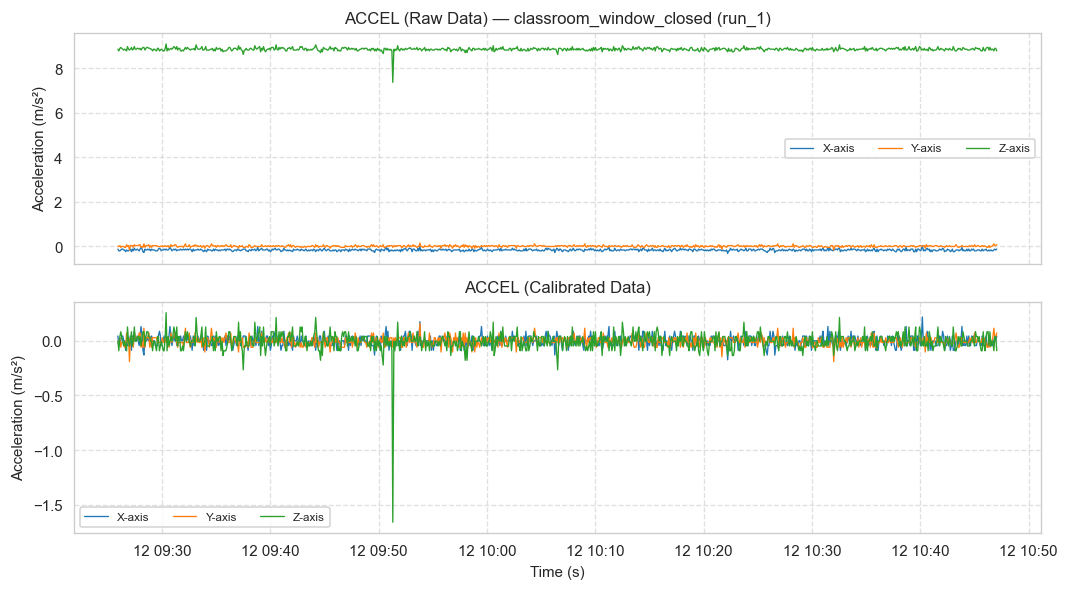

💾 Saved accel calibration figure: Dataset/classroom_window_closed_run_1/Figures/IMU_accel_calibration.png


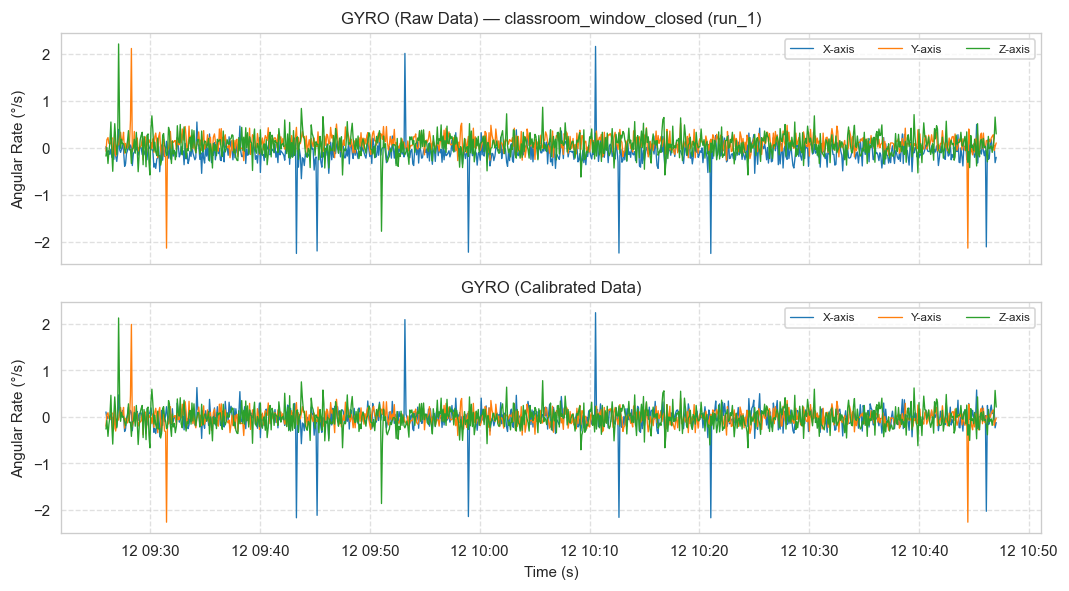

💾 Saved gyro calibration figure: Dataset/classroom_window_closed_run_1/Figures/IMU_gyro_calibration.png


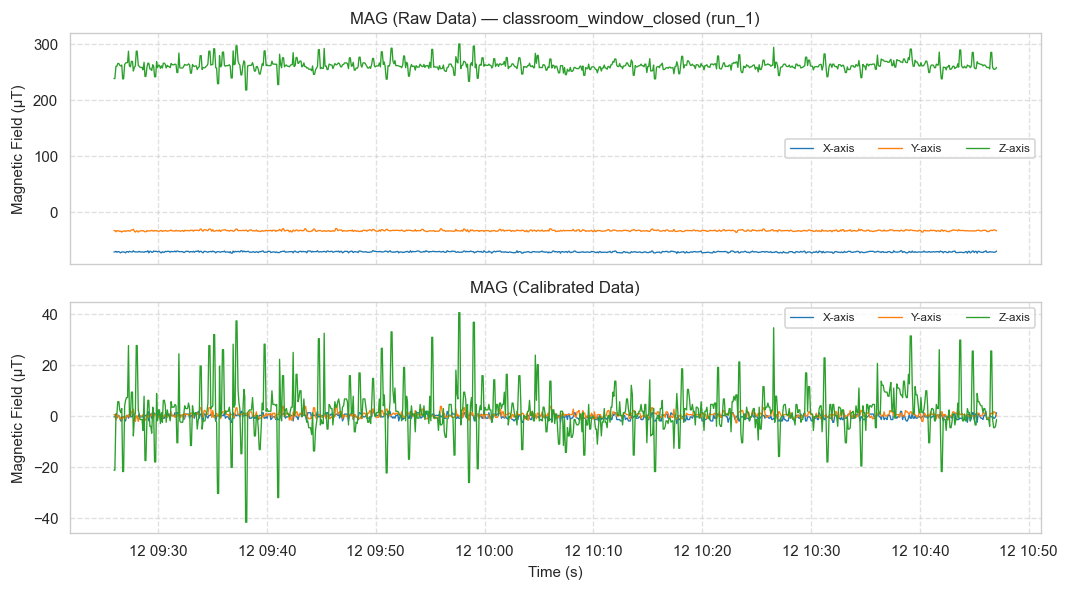

💾 Saved mag calibration figure: Dataset/classroom_window_closed_run_1/Figures/IMU_mag_calibration.png
⚠️  Spike flag column not found for co2_ppm, skipping.
⚠️  Spike flag column not found for pm25_ugm3, skipping.


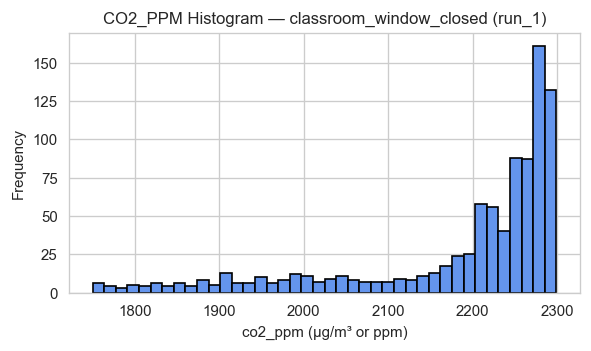

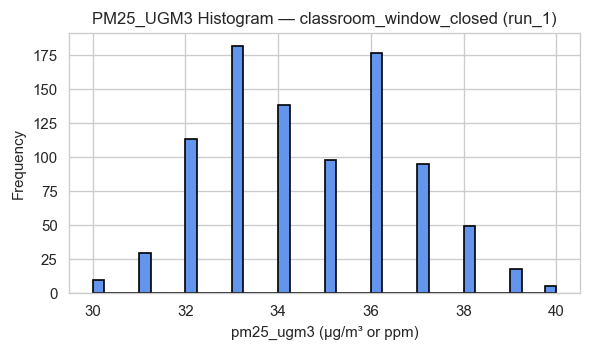

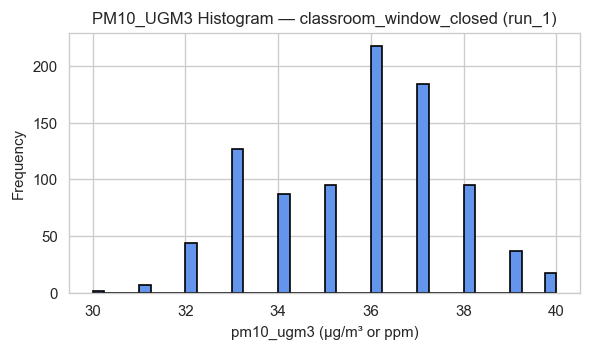

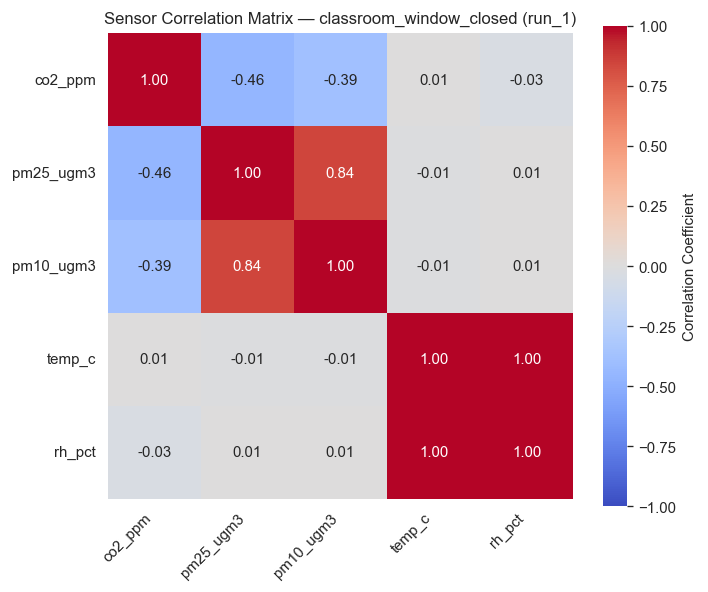

💾 Saved final dataset: Dataset/classroom_window_closed_run_1/Finalclassroom_window_closed_run_1.csv

=== Processing: mech_workshop | run_2 ===
✅ Created directories for: mech_workshop_run_2
Flatline counts: {'co2_ppm': 0, 'pm25_ugm3': 0, 'pm10_ugm3': 0, 'pm1_ugm3': 0, 'temp_c': 0, 'rh_pct': 0}
      sensor  n_valid  spikes_mad  spikes_rate  flatline_points
0    co2_ppm      508           0          0.0                0
1  pm25_ugm3      508           0          0.0                0
2  pm10_ugm3      508           0          0.0                0
3   pm1_ugm3      508           0          0.0                0


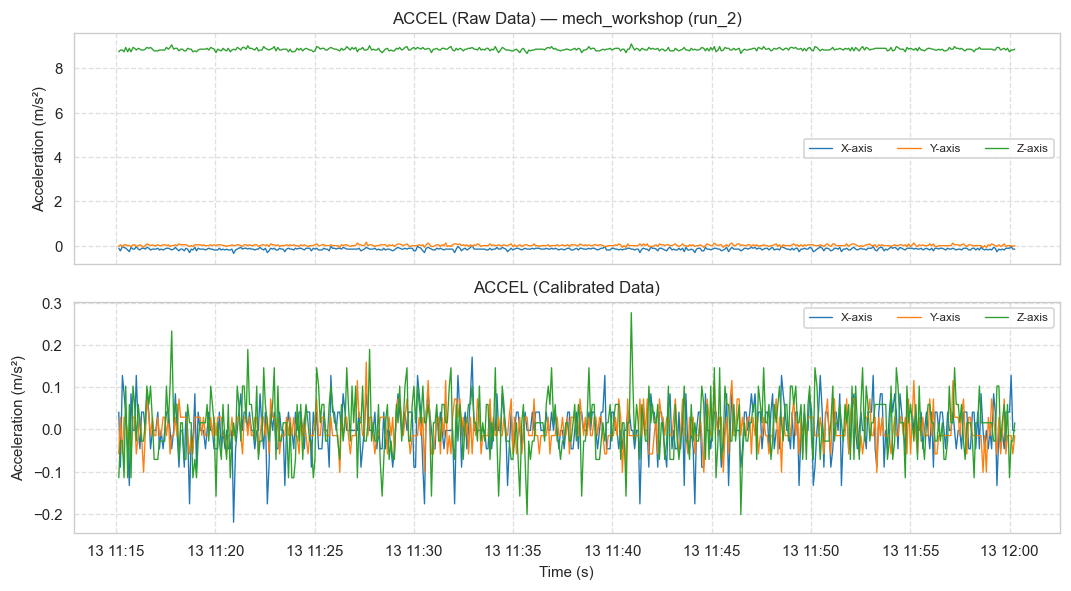

💾 Saved accel calibration figure: Dataset/mech_workshop_run_2/Figures/IMU_accel_calibration.png


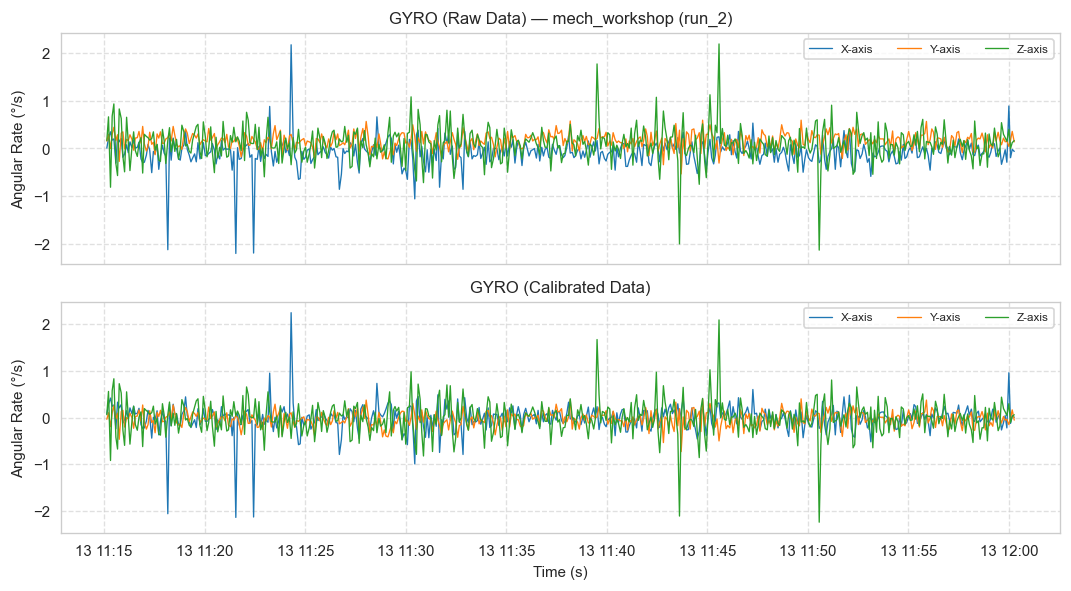

💾 Saved gyro calibration figure: Dataset/mech_workshop_run_2/Figures/IMU_gyro_calibration.png


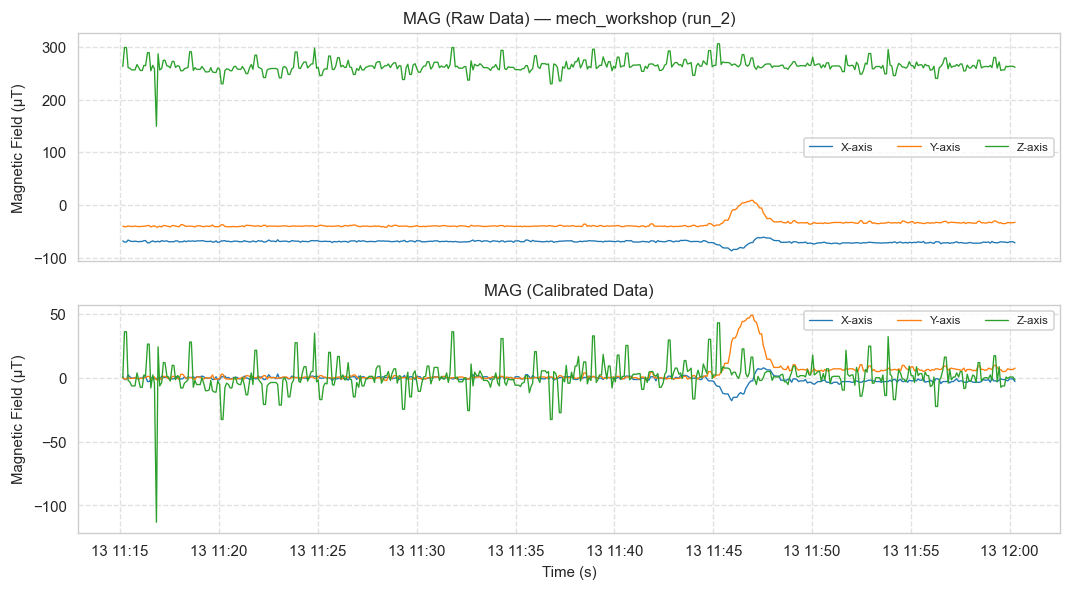

💾 Saved mag calibration figure: Dataset/mech_workshop_run_2/Figures/IMU_mag_calibration.png
⚠️  Spike flag column not found for co2_ppm, skipping.
⚠️  Spike flag column not found for pm25_ugm3, skipping.


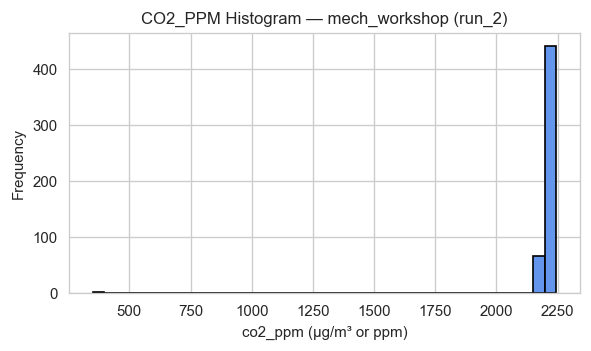

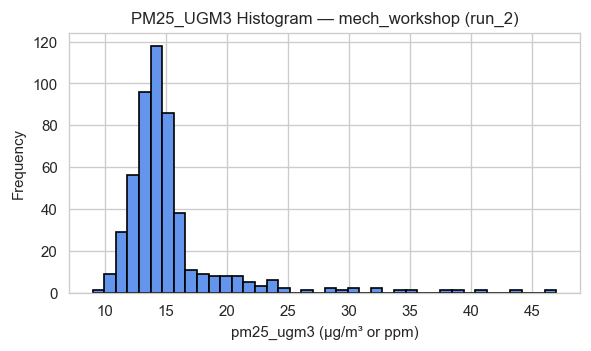

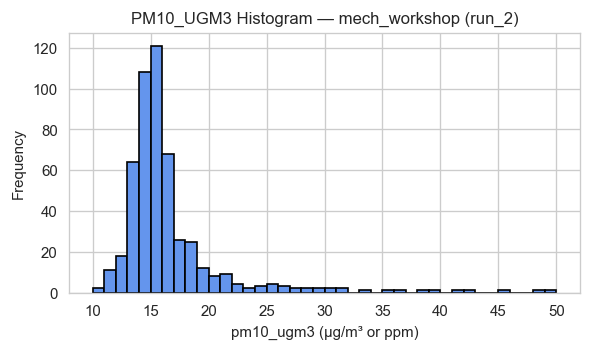

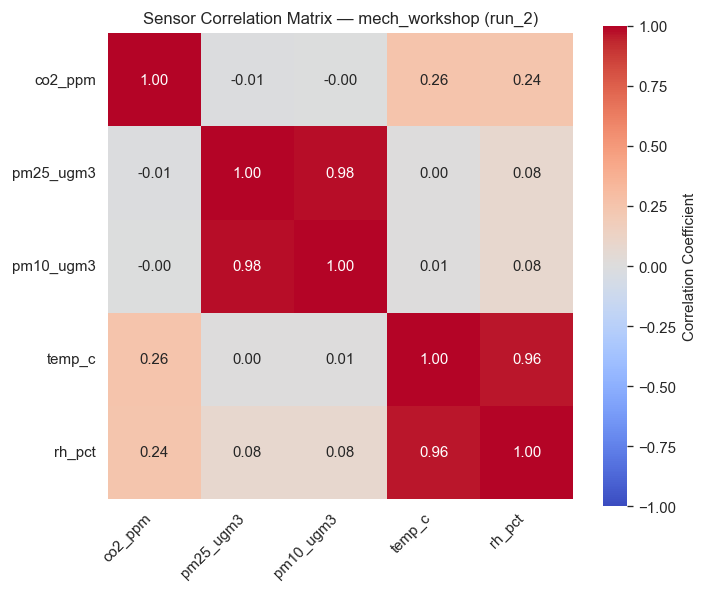

💾 Saved final dataset: Dataset/mech_workshop_run_2/Finalmech_workshop_run_2.csv

=== Processing: bedroom_window_open | run_3 ===
✅ Created directories for: bedroom_window_open_run_3
Flatline counts: {'co2_ppm': 0, 'pm25_ugm3': 0, 'pm10_ugm3': 0, 'pm1_ugm3': 0, 'temp_c': 0, 'rh_pct': 0}
      sensor  n_valid  spikes_mad  spikes_rate  flatline_points
0    co2_ppm      546           0          0.0                0
1  pm25_ugm3      546           0          0.0                0
2  pm10_ugm3      546           0          0.0                0
3   pm1_ugm3      546           0          0.0                0


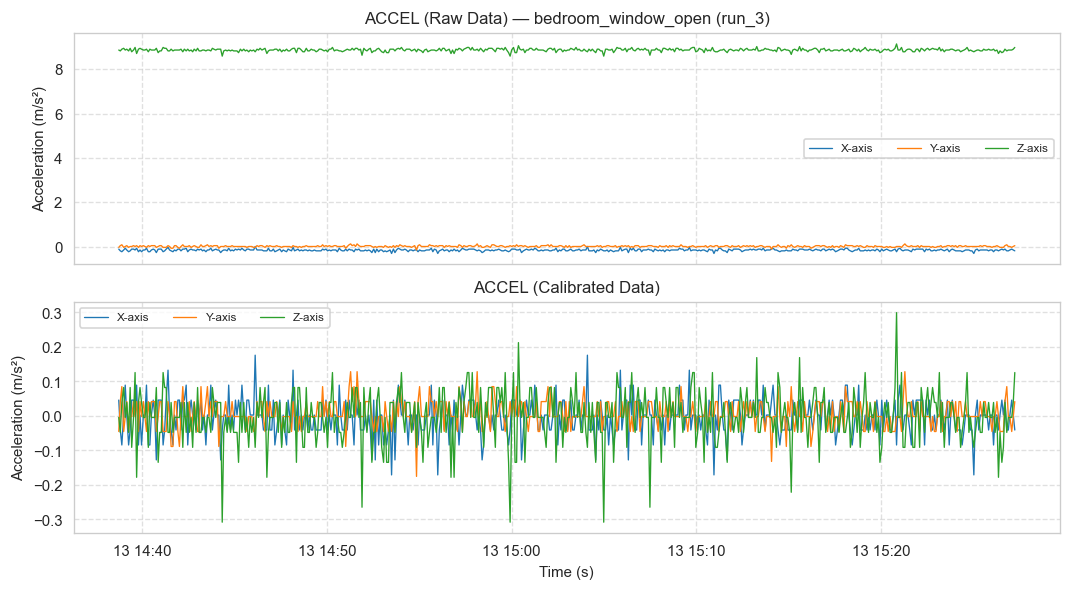

💾 Saved accel calibration figure: Dataset/bedroom_window_open_run_3/Figures/IMU_accel_calibration.png


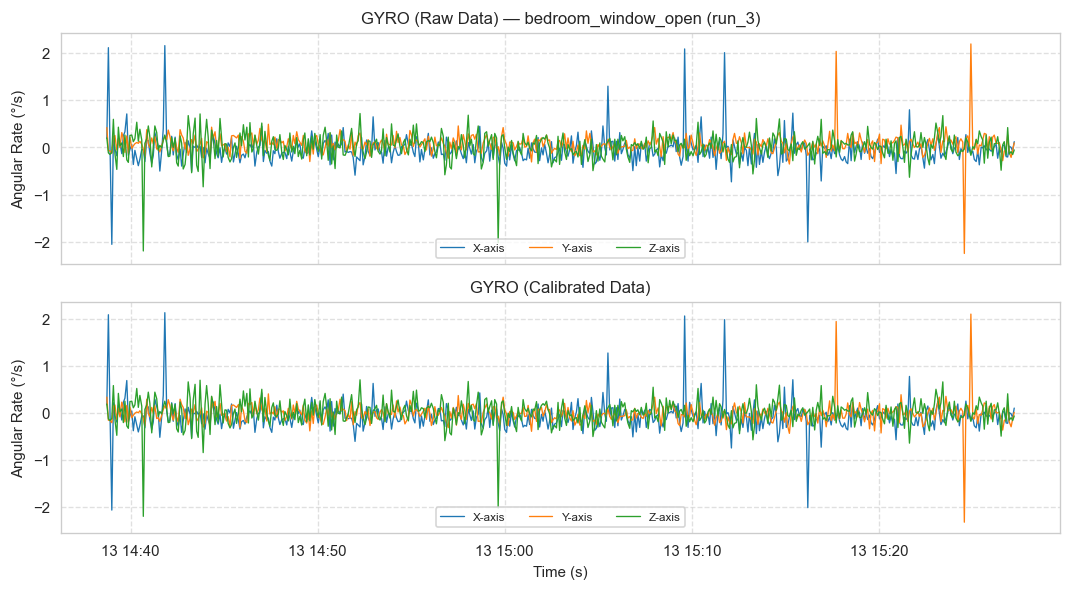

💾 Saved gyro calibration figure: Dataset/bedroom_window_open_run_3/Figures/IMU_gyro_calibration.png


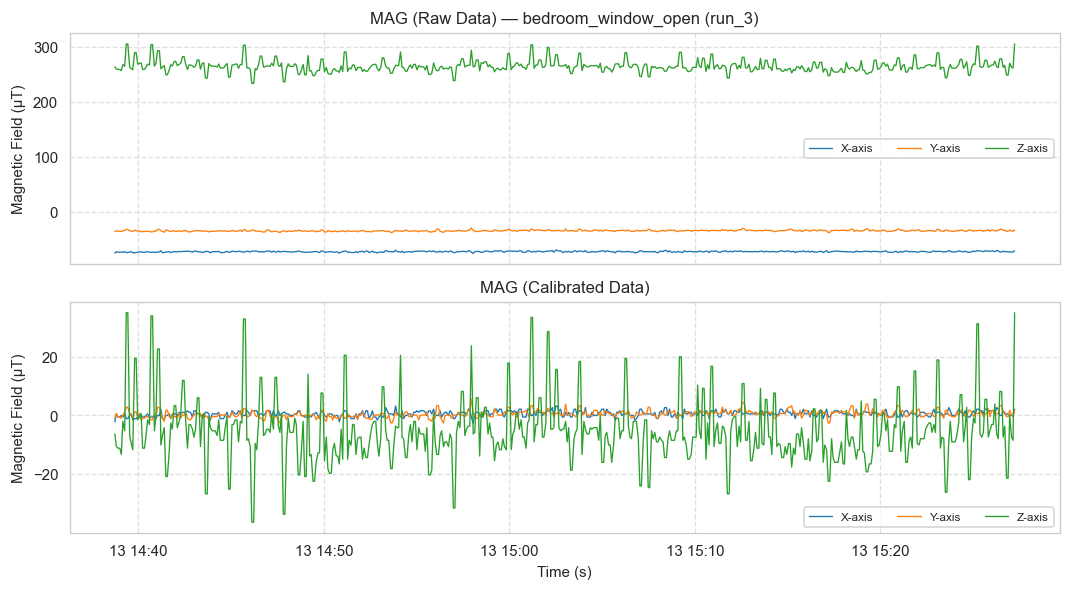

💾 Saved mag calibration figure: Dataset/bedroom_window_open_run_3/Figures/IMU_mag_calibration.png
⚠️  Spike flag column not found for co2_ppm, skipping.
⚠️  Spike flag column not found for pm25_ugm3, skipping.


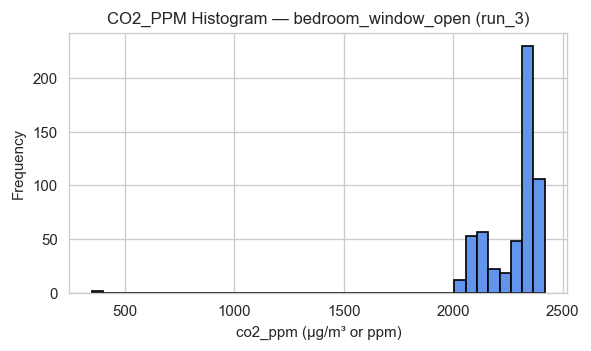

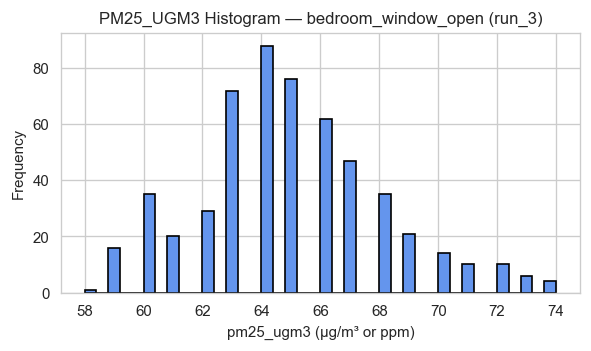

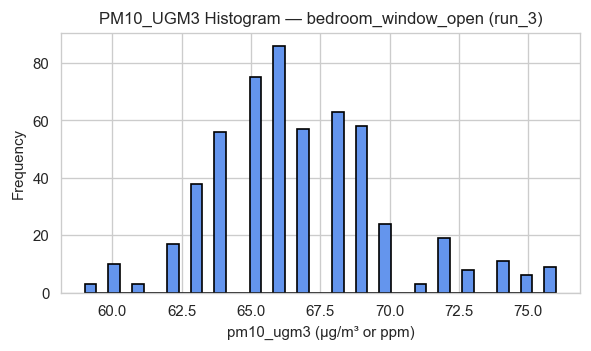

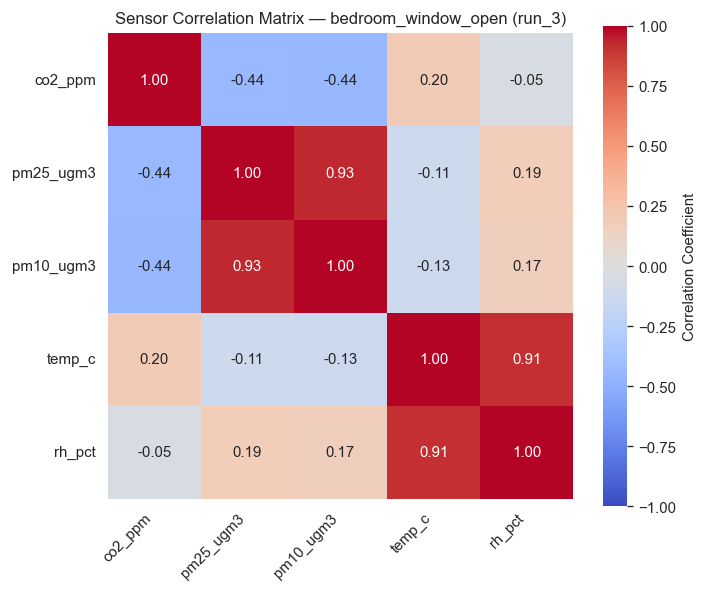

💾 Saved final dataset: Dataset/bedroom_window_open_run_3/Finalbedroom_window_open_run_3.csv

=== Processing: bedroom_window_closed | run_4 ===
✅ Created directories for: bedroom_window_closed_run_4
Flatline counts: {'co2_ppm': 0, 'pm25_ugm3': 0, 'pm10_ugm3': 0, 'pm1_ugm3': 0, 'temp_c': 0, 'rh_pct': 0}
      sensor  n_valid  spikes_mad  spikes_rate  flatline_points
0    co2_ppm      741           0          0.0                0
1  pm25_ugm3      741           0          0.0                0
2  pm10_ugm3      741           0          0.0                0
3   pm1_ugm3      741           0          0.0                0


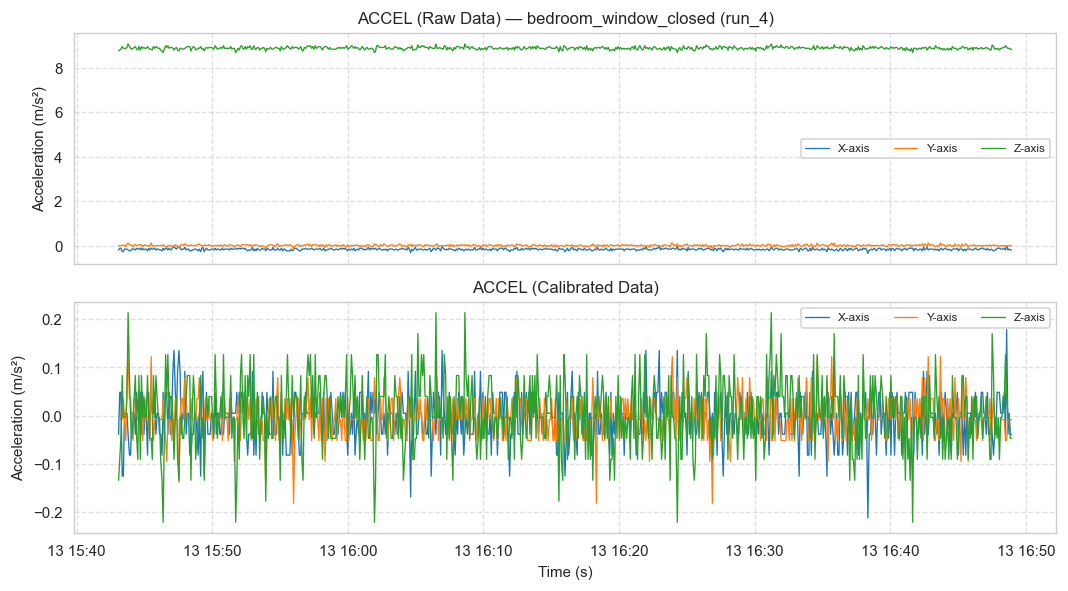

💾 Saved accel calibration figure: Dataset/bedroom_window_closed_run_4/Figures/IMU_accel_calibration.png


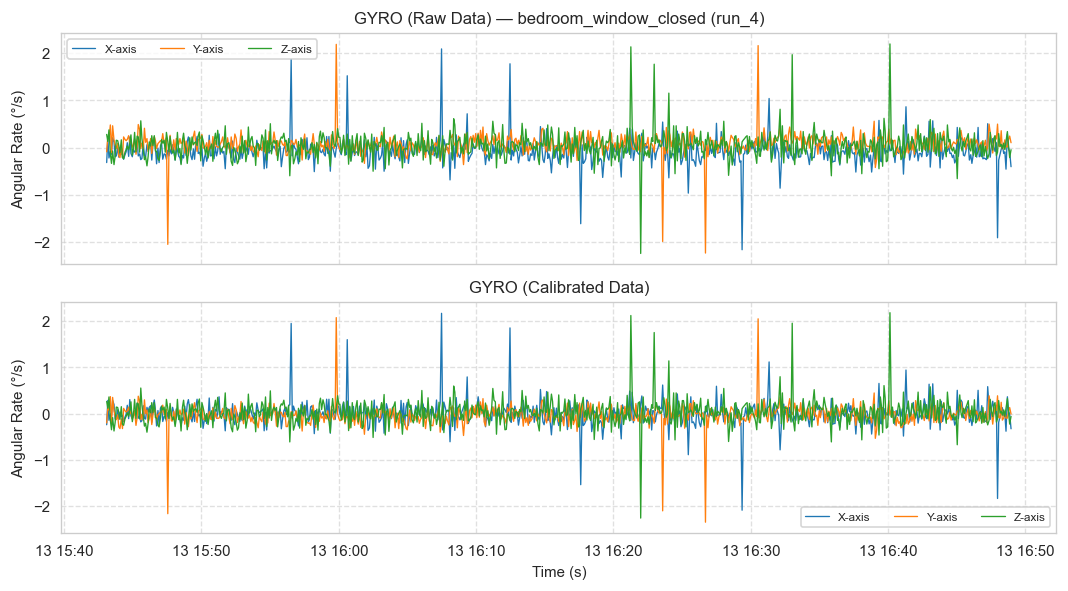

💾 Saved gyro calibration figure: Dataset/bedroom_window_closed_run_4/Figures/IMU_gyro_calibration.png


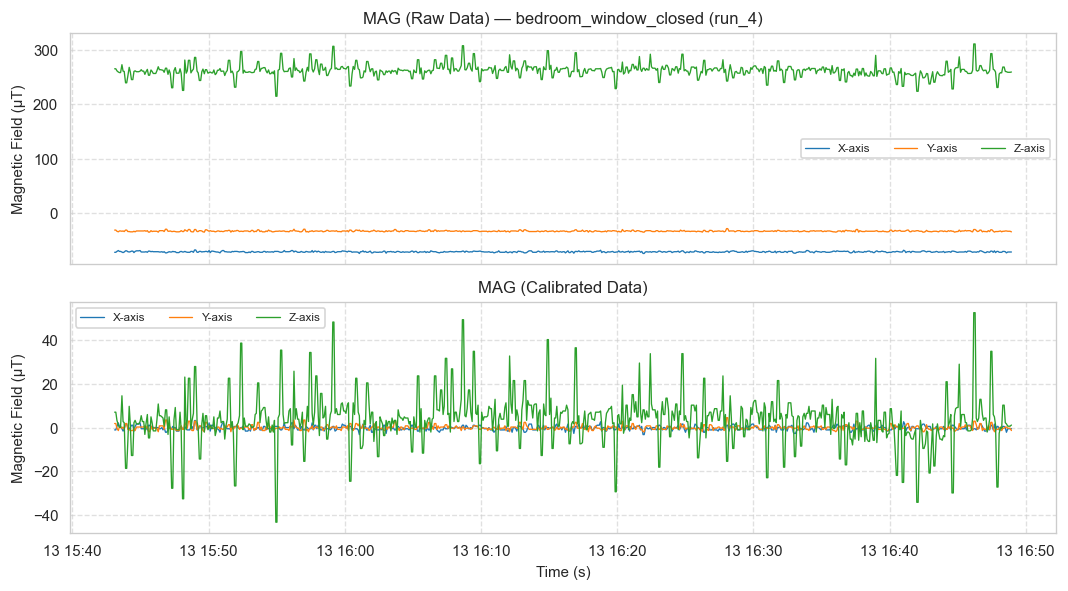

💾 Saved mag calibration figure: Dataset/bedroom_window_closed_run_4/Figures/IMU_mag_calibration.png
⚠️  Spike flag column not found for co2_ppm, skipping.
⚠️  Spike flag column not found for pm25_ugm3, skipping.


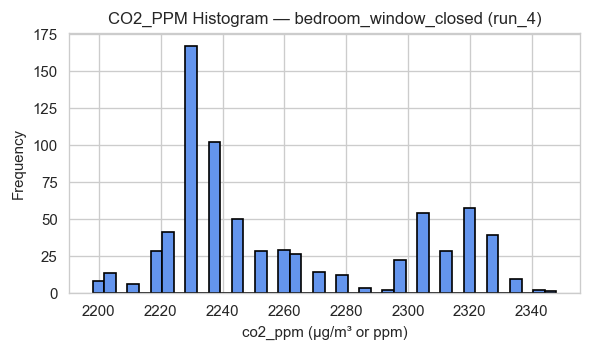

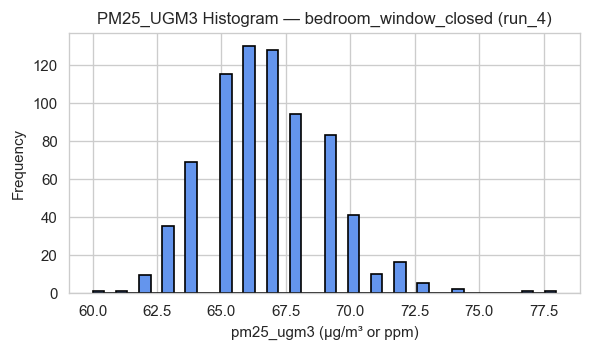

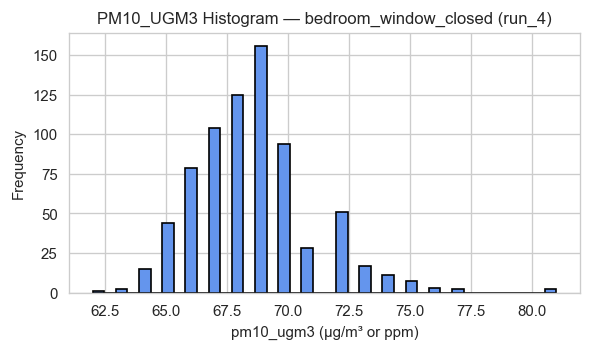

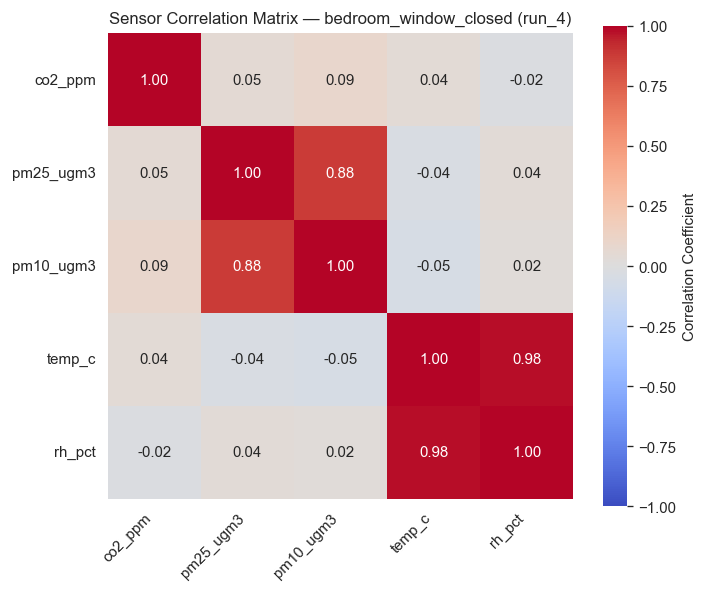

💾 Saved final dataset: Dataset/bedroom_window_closed_run_4/Finalbedroom_window_closed_run_4.csv


In [10]:
# ==========================================================
# Cell 7 — Group-wise Processing & Export (Final Integrated)
# ==========================================================

# 1. Ensure root dataset directory exists
os.makedirs(BASE_DATASET_DIR, exist_ok=True)

# 2. Identify all unique (room_label, run_id) pairs
group_keys = df[["room_label", "run_id"]].drop_duplicates()

for _, row in group_keys.iterrows():
    room_label = str(row["room_label"])
    run_id = str(row["run_id"])
    print(f"\n=== Processing: {room_label} | {run_id} ===")

    # ------------------------------------------------------
    # 3. Filter group data
    group_df = df[(df["room_label"] == room_label) & (df["run_id"] == run_id)].copy()

    # ------------------------------------------------------
    # 4. Create FAIR directory structure
    group_name = f"{room_label}_{run_id}"
    group_path = os.path.join(BASE_DATASET_DIR, group_name)
    figures_path = os.path.join(group_path, FIGURES_DIRNAME)
    lidar_path = os.path.join(group_path, LIDAR_CAMERA_DIRNAME)
    os.makedirs(group_path, exist_ok=True)
    os.makedirs(figures_path, exist_ok=True)
    os.makedirs(lidar_path, exist_ok=True)
    print(f"✅ Created directories for: {group_name}")

    # ------------------------------------------------------
    # 5. Flatline Detection
    flatline_counts = {}
    for col in ["co2_ppm", "pm25_ugm3", "pm10_ugm3", "pm1_ugm3", "temp_c", "rh_pct"]:
        if col not in group_df.columns:
            continue
        count, flag = detect_flatline(group_df[col])
        group_df[f"{col}_flatline_flag"] = flag.astype(int)
        flatline_counts[col] = count
    print("Flatline counts:", flatline_counts)

    # ------------------------------------------------------
    # 6. QC Summary
    qc_summary = []
    for col in ["co2_ppm", "pm25_ugm3", "pm10_ugm3", "pm1_ugm3"]:
        if col not in group_df.columns:
            continue
        n_valid = group_df[col].notna().sum()
        n_spikes = group_df.get(f"{col}_spike_flag", pd.Series(0)).sum()
        spikes_rate = n_spikes / max(n_valid, 1)
        flatline_points = flatline_counts.get(col, 0)
        qc_summary.append({
            "sensor": col,
            "n_valid": int(n_valid),
            "spikes_mad": int(n_spikes),
            "spikes_rate": round(spikes_rate, 4),
            "flatline_points": int(flatline_points)
        })
    qc_df = pd.DataFrame(qc_summary)
    qc_path = os.path.join(figures_path, "QC_Summary.csv")
    qc_df.to_csv(qc_path, index=False)
    print(qc_df)

    # ------------------------------------------------------
    # 7. Environmental Sensor Calibration (Linear)
    for sensor, params in calibration_constants.items():
        if sensor not in group_df.columns or "a" not in params["params"]:
            continue
        a = params["params"]["a"]
        b = params["params"]["b"]
        group_df[f"{sensor}_corr"] = group_df[sensor] * a + b

    # ------------------------------------------------------
    # 8. IMU Calibration & Plots
    group_df, imu_calibration = calibrate_and_plot_imu(
        group_df=group_df,
        room_label=room_label,
        run_id=run_id,
        output_dir=figures_path
    )
    with open(os.path.join(group_path, "calibration.json"), "w") as f:
        json.dump(imu_calibration, f, indent=4)

    # ------------------------------------------------------
    # 9. Rolling Statistics
    for col in ["co2_ppm", "pm25_ugm3", "pm10_ugm3"]:
        group_df = add_rolling_features(group_df, col)

    # ------------------------------------------------------
    # 10. Gradients (Rates of Change)
    for col in ["co2_ppm", "pm25_ugm3"]:
        if col in group_df.columns:
            group_df[f"{col}_d_dt"] = group_df[col].diff() * SAMPLING_RATE

    # ------------------------------------------------------
    # 11. Psychrometric Features
    if {"temp_c", "rh_pct"}.issubset(group_df.columns):
        group_df["dew_point_c"] = dew_point(group_df["temp_c"], group_df["rh_pct"])
        group_df["abs_humidity"] = absolute_humidity(group_df["temp_c"], group_df["rh_pct"])

    # ------------------------------------------------------
    # 12. CO₂ Air-Quality Category
    if "co2_ppm" in group_df.columns:
        bins_co2 = [0, 800, 1200, 2000, np.inf]
        labels_co2 = ["Good", "Moderate", "Poor", "Very Poor"]
        group_df["co2_category"] = pd.cut(group_df["co2_ppm"], bins=bins_co2, labels=labels_co2)

    # ------------------------------------------------------
    # 13. Temporal Context
    if "timestamp" in group_df.columns:
        group_df["hour"] = group_df["timestamp"].dt.hour
        group_df["weekday"] = group_df["timestamp"].dt.weekday

    # ------------------------------------------------------
    # 14. Hourly Summary
    group_df["hour_ts"] = group_df["timestamp"].dt.floor("h")
    hourly = group_df.groupby("hour_ts").agg({
        "co2_ppm": ['mean', 'std', 'min', 'max'],
        "pm25_ugm3": ['mean', 'std', 'min', 'max'],
        "temp_c": ['mean', 'std'],
        "rh_pct": ['mean', 'std']
    }).reset_index()
    hourly.columns = ["hour_ts"] + ["_".join(c).strip("_") for c in hourly.columns[1:]]
    hourly.to_csv(os.path.join(figures_path, "HourlySummary.csv"), index=False)

    # ------------------------------------------------------
    # 15. Metadata File
    metadata = {
        "dataset_name": f"Processed IAQ Data - {room_label}, {run_id}",
        "room_label": room_label,
        "run_id": run_id,
        "sampling_rate_hz": SAMPLING_RATE,
        "sensors": list(calibration_constants.keys()),
        "qc_metrics": list(qc_df.columns),
        "derived_features": [
            "*_roll_mean", "*_roll_std", "*_d_dt",
            "dew_point_c", "abs_humidity", "co2_category"
        ],
        "imu_calibration": imu_calibration,
        "columns": list(group_df.columns),
        "license": "CC-BY-4.0",
        "version": "1.0"
    }
    with open(os.path.join(group_path, "metadata.json"), "w") as f:
        json.dump(metadata, f, indent=4)

    # ------------------------------------------------------
    # 16. Spike Detection Plots
    plot_spike_detection_group(
        group_df=group_df,
        room_label=room_label,
        run_id=run_id,
        variables=["co2_ppm", "pm25_ugm3"],
        output_dir=figures_path
    )

    # ------------------------------------------------------
    # 17. Histograms
    for pollutant in ["co2_ppm", "pm25_ugm3", "pm10_ugm3"]:
        if pollutant not in group_df.columns:
            continue
        plt.figure(figsize=(5, 3))
        plt.hist(group_df[pollutant].dropna(), bins=40,
                 color="cornflowerblue", edgecolor="black")
        plt.title(f"{pollutant.upper()} Histogram — {room_label} ({run_id})")
        plt.xlabel(f"{pollutant} (µg/m³ or ppm)")
        plt.ylabel("Frequency")
        plt.tight_layout()
        hist_path = os.path.join(figures_path, f"Histogram_{pollutant}.png")
        plt.savefig(hist_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

    # ------------------------------------------------------
    # 18. Correlation Plot (annotated)
    corr_cols = [c for c in ["co2_ppm", "pm25_ugm3", "pm10_ugm3", "temp_c", "rh_pct"] if c in group_df.columns]
    if len(corr_cols) >= 2:
        corr = group_df[corr_cols].corr()
        plt.figure(figsize=(6, 5))
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                    cbar_kws={"label": "Correlation Coefficient"},
                    square=True, vmin=-1, vmax=1)
        plt.title(f"Sensor Correlation Matrix — {room_label} ({run_id})")
        plt.xticks(rotation=45, ha="right")
        plt.yticks(rotation=0)
        plt.tight_layout()
        corr_path = os.path.join(figures_path, "CorrelationMatrix.png")
        plt.savefig(corr_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

    # ------------------------------------------------------
    # 19. Save Final Dataset
    final_path = os.path.join(group_path, f"Final{room_label}_{run_id}.csv")
    group_df.to_csv(final_path, index=False)
    print(f"💾 Saved final dataset: {final_path}")
